# Tunneling
**PHYS 309:  Physics of the Twentieth and Twenty-First Century**  
Adriana Buvac-Drndic <br>
 17 May 2026

<br>

---
<br>
Quantum tunneling is when a particle has a small probability of passing through a barrier even though it does not have enough energy to cross it classically. Classically, the particle would be blocked, but in quantum mechanics particles are described by wave functions, which can extend into and sometimes through the barrier. This makes tunneling one of the clearest examples of behavior that is not classical, and it helps explain real physical phenomena like alpha decay, tunnel diodes, and scanning tunneling microscopes.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import constants

plt.rcParams.update({'font.size': 16, 'axes.labelsize': 16})

## 1. Introduction

Classical mechanics teaches us that a particle cannot cross a barrier when its total energy is less than the barrier height, $E < V_0$. You can think about this as a ball rolling toward a hill. If the ball does not have enough energy to reach the top, it rolls back down instead.

Quantum mechanics gives a different result because particles are modeled by wave functions rather than a classical path. If the energy is smaller than the barrier height, the wave function does not go to zero inside the barrier. Instead, it can have a limited probability of being on the other side. That is exactly why tunneling is one of the most obvious manifestations of behavior that is not classical.

**Key comparisons between classical and quantum predictions:**

| Case| Classical prediction | Quantum prediction|
|---|---|---|
| $E > V_0$ | Full transmission (no reflection) | Mostly transmitted, some reflection possible |
| $E < V_0$ | Total reflection | Mostly reflected, small but finite transmission |

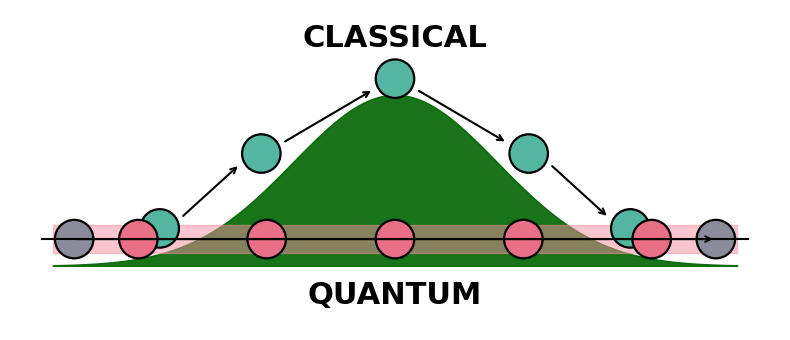

In [12]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
bg = "white"
fig.patch.set_facecolor(bg)
ax.set_facecolor(bg)
ax.set_aspect("equal")
ax.axis("off")
ax.set_xlim(-3.6, 3.6)
ax.set_ylim(-0.6, 2.4)

x = np.linspace(-3.2, 3.2, 400)
V = 1.6 * np.exp(-0.55 * x**2)

ax.fill_between(x, 0, V, color="darkgreen", alpha=0.9)

E = 0.25
ax.fill_between(x, E - 0.13, E + 0.13, color="#f58fa1", alpha=0.5)
ax.plot([-3.3, 3.3], [E, E], color="black", lw=1.5)

def ball(x, y, color):
    c = plt.Circle((x, y), 0.18, facecolor=color, edgecolor="black", lw=1.6)
    ax.add_patch(c)

classic = [(-2.2, 0.35), (-1.25, 1.05), (0, 1.75), (1.25, 1.05), (2.2, 0.35)]

for x0, y0 in classic:
    ball(x0, y0, "#54b6a0")

quantum = [-2.4, -1.2, 0, 1.2, 2.4]

for x0 in quantum:
    ball(x0, E, "#e96f87")

ball(-3.0, E, "#8b8b9b")
ball(3.0, E, "#8b8b9b")

arrow = dict(arrowstyle="->", color="black", lw=1.5)
ax.annotate("", xy=(-1.45, 0.95), xytext=(-2.0, 0.45), arrowprops=arrow)
ax.annotate("", xy=(-0.2, 1.65), xytext=(-1.05, 1.15), arrowprops=arrow)
ax.annotate("", xy=(1.05, 1.15), xytext=(0.2, 1.65), arrowprops=arrow)
ax.annotate("", xy=(2.0, 0.45), xytext=(1.45, 0.95), arrowprops=arrow)
ax.annotate("", xy=(3.0, E), xytext=(-3.0, E), arrowprops=arrow)

ax.text(0, 2.05, "CLASSICAL", ha="center", fontsize=22, fontweight="bold")
ax.text(0, -0.35, "QUANTUM", ha="center", fontsize=22, fontweight="bold")

plt.tight_layout()
plt.show()

Classical vs. Quantum visualization

## 2. Wave Analogy and Evanescent Waves

A helpful analogy for quantum tunneling comes from optics: **total internal reflection.** When light inside a prism hits a surface at an angle greater than the critical angle, most of the light reflects back into the prism instead of passing through. However, the electric field does not stop completely at the boundary. A small evanescent wave extends a short distance into the second medium and quickly fades away. The evanescent wave is essentially a leftover wave that leaks past the boundary.
<br><br>
This is similar to a quantum wave function inside a barrier. Even when transmission is mostly blocked, the wave can still extend slightly into the barrier. If another medium is placed very close by, some light can appear there, giving a classical wave analogy for quantum tunneling.

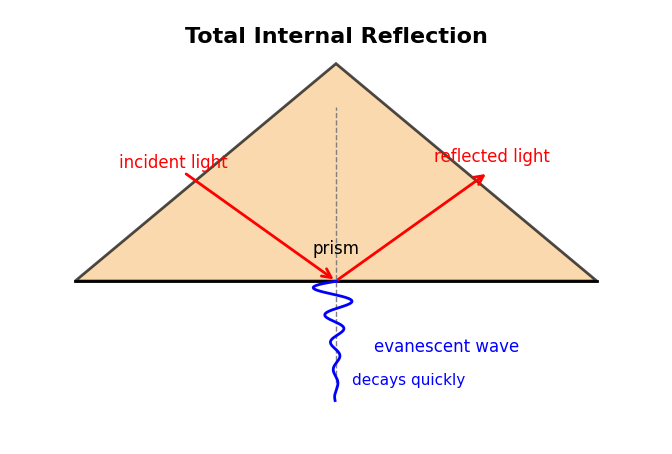

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

# setup
fig, ax = plt.subplots(figsize=(7, 5))

ax.set_xlim(-3, 3)
ax.set_ylim(-2, 2)
ax.set_aspect("equal")
ax.axis("off")

# colors
bg = "white"
prism_color = "#f7c98b"
light_color = "red"
wave_color = "blue"
line_color = "black"

fig.patch.set_facecolor(bg)
ax.set_facecolor(bg)

# prism
prism = Polygon(
    [(-2.4, -0.5), (0, 1.5), (2.4, -0.5)],
    closed=True,
    facecolor=prism_color,
    edgecolor=line_color,
    linewidth=2,
    alpha=0.7
)
ax.add_patch(prism)

ax.plot([-2.4, 2.4], [-0.5, -0.5], color=line_color, lw=2)

hit = (0, -0.5)

# incident light ray
ax.annotate(
    "",
    xy=hit,
    xytext=(-1.4, 0.5),
    arrowprops=dict(arrowstyle="->", color=light_color, lw=2)
)

# reflected light ray
ax.annotate(
    "",
    xy=(1.4, 0.5),
    xytext=hit,
    arrowprops=dict(arrowstyle="->", color=light_color, lw=2)
)

# normal line
ax.plot([0, 0], [-1.5, 1.1], "--", color="gray", lw=1)

# evanescent wave below the prism
y = np.linspace(-0.5, -1.6, 300)
amp = 0.25 * np.exp(-2.8 * (y + 0.5) * -1)
x = amp * np.sin(25 * y)

ax.plot(x, y, color=wave_color, lw=2)

# labels
ax.text(-2.0, 0.55, "incident light", color=light_color, fontsize=12)
ax.text(0.9, 0.6, "reflected light", color=light_color, fontsize=12)
ax.text(0.35, -1.15, "evanescent wave", color=wave_color, fontsize=12)
ax.text(0.15, -1.45, "decays quickly", color=wave_color, fontsize=11)

ax.text(0, 1.7, "Total Internal Reflection", ha="center", fontsize=16, fontweight="bold")
ax.text(0, -0.25, "prism", ha="center", fontsize=12)

plt.tight_layout()
plt.show()

## 3. Finite Square Potential Barrier

The finite square potential barrier is the fundamental mathematical model of tunneling. In this system, a particle approaches a barrier of height $V_0$ and width $L$. The space is divided into three regions:

- **Region I** ($x < 0$): $V = 0$
- **Region II** ($0 < x < L$): $V = V_0$
- **Region III** ($x > L$): $V = 0$

The behavior of the particle is described using the **time-independent Schrödinger equation**:

### $-\frac{\hbar^2}{2m}\frac{d^2\psi}{dx^2} + V\psi = E\psi$

This equation determines the shape of the wave function for each region and allows us to find the probability of reflection and transmission.

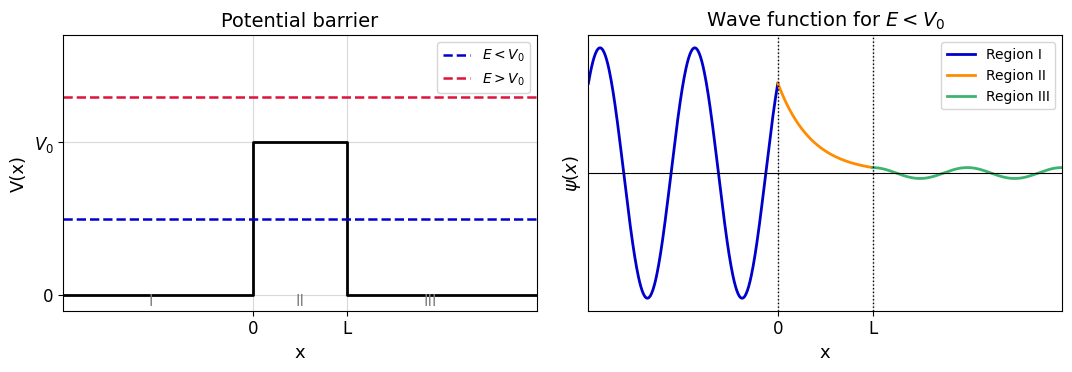

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

#right side, Potential barrier
xbar = [-2, 0, 0, 1, 1, 3]
Vbar = [0, 0, 1, 1, 0, 0]
ax1.plot(xbar, Vbar, color='black', lw=2)

ax1.axhline(0.5, color='mediumblue', ls='--', lw=1.8, label=r'$E < V_0$')
ax1.axhline(1.3, color='crimson', ls='--', lw=1.8, label=r'$E > V_0$')
ax1.set_xlim(-2, 3)
ax1.set_ylim(-0.1, 1.7)
ax1.set_xlabel('x', fontsize=13)
ax1.set_ylabel('V(x)', fontsize=13)
ax1.set_title('Potential barrier', fontsize=14)

ax1.set_xticks([0, 1])
ax1.set_xticklabels(['0', 'L'], fontsize=12)
ax1.set_yticks([0, 1])
ax1.set_yticklabels(['0', r'$V_0$'], fontsize=12)
ax1.legend(fontsize=10, loc='upper right')
#labels
ax1.text(-1.1, -0.07, 'I', fontsize=11, color='gray')
ax1.text(0.45, -0.07, 'II', fontsize=11, color='gray')
ax1.text(1.8, -0.07, 'III', fontsize=11, color='gray')

ax1.grid(color='0.85')

#left side, wave function

xI = np.linspace(-2, 0, 300)
xII = np.linspace(0, 1, 200)
xIII = np.linspace(1, 3, 300)
k = 2 * np.pi
kappa = 2.8

#region 1
wvI = 0.6 * np.sin(k * xI + 0.8)
psi0 = wvI[-1]

#region 2
wvII = psi0 * np.exp(-kappa * xII)
psiL = wvII[-1]
#region 3
wvIII = psiL * np.cos(k * (xIII - 1))
ax2.plot(xI, wvI, color='mediumblue', lw=2, label='Region I')
ax2.plot(xII, wvII, color='darkorange', lw=2, label='Region II')
ax2.plot(xIII, wvIII, color='mediumseagreen', lw=2, label='Region III')

# barriers and titles
ax2.axvline(0, color='black', ls=':', lw=1)
ax2.axvline(1, color='black', ls=':', lw=1)
ax2.axhline(0, color='black', lw=0.8)
ax2.set_xlim(-2, 3)
ax2.set_xlabel('x', fontsize=13)
ax2.set_ylabel(r'$\psi(x)$', fontsize=13)
ax2.set_title(r'Wave function for $E < V_0$', fontsize=14)
ax2.set_xticks([0, 1])
ax2.set_xticklabels(['0', 'L'], fontsize=12)
ax2.set_yticks([])
ax2.legend(fontsize=10, loc='upper right')
ax2.grid(color='0.85')

plt.tight_layout()
plt.show()

- When $E > V_0$

If $E > V_0$, then classical mechanics says the particle has to pass through the barrier completely. But because the particle is wave-like, quantum mechanics predicts that it can still be partially reflected. At the boundary of the barrier, the wave function can interfere with itself, resulting in reflected and transmitted waves. If some resonance conditions are satisfied, reflected waves cancel, allowing full transmission. This resembles wave behavior in optics, where reflected and transmitted waves depend on different conditions, including wavelength, phase, and boundaries. <br>

In Regions I and III where $V = 0$ the wave number is:

### $k_\mathrm{I} = k_\mathrm{III} = \frac{\sqrt{2mE}}{\hbar}$

Inside the barrier ($V = V_0$):

### $k_\mathrm{II} = \frac{\sqrt{2m(E - V_0)}}{\hbar}$

The wave functions in each region are (Eqs. 6.63a–c in Thornton & Rex):

### $\psi_\mathrm{I}(x) = Ae^{ik_\mathrm{I}x} + Be^{-ik_\mathrm{I}x}$

### $\psi_\mathrm{II}(x) = Ce^{ik_\mathrm{II}x} + De^{-ik_\mathrm{II}x}$

### $\psi_\mathrm{III}(x) = Fe^{ik_\mathrm{I}x}$

We set $G = 0$ because there are no particles initially moving in the $-x$ direction in Region III. The transmission probability (Eq. 6.67) is:

### $T = \left[1 + \frac{V_0^2\,\sin^2(k_\mathrm{II}L)}{4E(E - V_0)}\right]^{-1}$

The incident and reflected waves cancel completely, which resembles anti-reflection coatings in optics.

- When $E < V_0$: Tunneling

This is the main tunneling case. Classically, the particle is not able to cross the barrier because it does not have enough energy. In quantum mechanics, the barrier region is classically forbidden, but the wave function does enter and exponentially decreases instead of instantly becoming zero. As the wave function is nonzero inside the barrier, there will be a small, finite probability that the particle moves toward the far side and ends up in Region III.

Because $E < V_0$, the quantity $(E - V_0)$ is negative, so $k_\mathrm{II}$ becomes imaginary. We replace $ik_\mathrm{II} \to \kappa$ where:

### $\kappa = \frac{\sqrt{2m(V_0 - E)}}{\hbar}$

The wave function inside the barrier becomes (Eq. 6.68):

### $\psi_\mathrm{II}(x) = Ce^{+\kappa x} + De^{-\kappa x}$

For a wide barrier the $e^{+\kappa x}$ term grows unphysically, so the dominant surviving piece is:

### $\psi_\mathrm{II}(x) \propto e^{-\kappa x}$
<br>
Thus tunneling is strongly linked to the barrier height, the barrier width, and the energy of the particle. A wider and/or taller barrier causes the wave function to decay more and creates a smaller likelihood of tunneling.

## 4. Transmission Probability

The transmission probability refers to how likely it is for a particle to tunnel through the barrier. If the barrier is wide or very high, the tunneling probability is approximately:

$$
T \approx e^{-2\kappa L}
$$


| Parameter | Effect on Transmission Probability, $T$ |
|---|---|
| Barrier width $L$ increases | $T$ decreases exponentially ($e^{-2\kappa L}$) |
| Barrier height $V_0$ increases | $T$ decreases ( $\kappa \sim \sqrt{V_0-E}$, square-root dependence) |
| Particle energy $E$ increases | $T$ increases ($\kappa$ decreases) |
| Particle mass $m$ increases | $T$ decreases ($\kappa \sim \sqrt{m}$, so heavier particles tunnel less) |

<br> The textbook mentions that barrier width contributes strongly to tunneling because it is placed directly in the exponential factor.

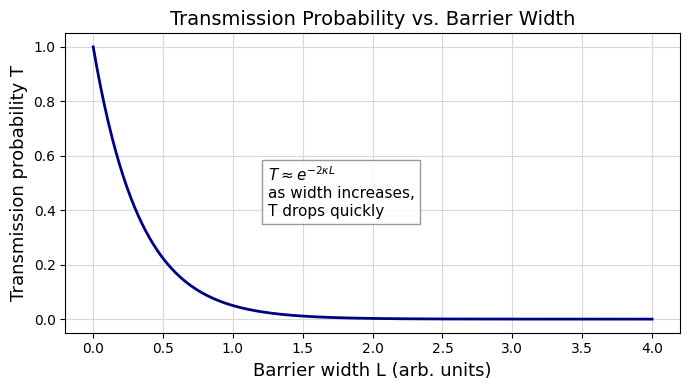

In [3]:
import numpy as np
import matplotlib.pyplot as plt

L = np.linspace(0, 4, 300)
kappa = 1.5

T = np.exp(-2 * kappa * L)

plt.figure(figsize=(7, 4))

plt.plot(L, T, color='navy', lw=2)

plt.xlabel('Barrier width L (arb. units)', fontsize=13)
plt.ylabel('Transmission probability T', fontsize=13)
plt.title('Transmission Probability vs. Barrier Width', fontsize=14)

plt.grid(color='0.85')

plt.text(
    1.25, 0.38,
    r'$T \approx e^{-2\kappa L}$' + '\n' +
    'as width increases,\nT drops quickly',
    fontsize=11,
    bbox=dict(facecolor='white', edgecolor='gray', alpha=0.8)
)

plt.tight_layout()
plt.show()

## 5. Connection to the Uncertainty Principle

The uncertainty principle is another reason that tunneling is permitted in quantum mechanics. The position–momentum uncertainty relation is:

### $\Delta x \, \Delta p \geq \frac{\hbar}{2}$

Inside the barrier, the wave function $\psi_\mathrm{II}$ is dominated by the $e^{-\kappa x}$ term, so the probability density $|\psi_\mathrm{II}|^2 \approx e^{-2\kappa x}$ falls by a factor of $e^{-2}$ over a distance $\Delta x = \kappa^{-1}$. From the uncertainty principle:

### $\Delta p \geq \frac{\hbar}{\Delta x} = \hbar\kappa$

The minimum kinetic energy associated with this momentum uncertainty is:

### $K_\mathrm{min} = \frac{(\Delta p)^2}{2m} = \frac{\hbar^2 \kappa^2}{2m} = V_0 - E$

The violation allowed by the uncertainty principle ($K_\mathrm{min}$) is equal to the *negative* kinetic energy required! Tunneling does not violate conservation of energy because the particle is not actually gaining enough energy to climb over the barrier — the wave function simply extends into the classically forbidden region.

## 6. Real-World Applications

### Alpha Decay

Quantum tunneling accounts for alpha decay in radioactive nuclei. Because of the nuclear potential and the Coulomb barrier, an alpha particle can be trapped inside a heavy nucleus. Classically, it should not escape because its energy is not high enough to overcome the barrier.

However, quantum mechanics allows the alpha particle to tunnel through the barrier and leave the nucleus. This explains why some radioactive nuclei decay even though the emitted alpha particles do not have enough classical energy to escape. Small differences in the barrier can cause large changes in the decay rate because tunneling probability depends exponentially on the barrier properties.

### Scanning Tunneling Microscope (STM)

A scanning tunneling microscope, or STM, uses quantum tunneling to image surfaces at the atomic scale. A conducting tip is brought very close to a surface, and electrons tunnel across the tiny gap between the tip and the sample.

The tunneling current depends strongly on the tip-surface distance:

$$
I \propto e^{-2\kappa d}
$$

Even a tiny change in distance leads to a large change in current. For example, the textbook notes that a change of only $0.4\,\text{nm}$ in the tunneling gap can cause a factor of $10^4$ change in the tunneling current. This makes STM sensitive enough to detect atomic-scale surface features.

### Tunnel Diode

A tunnel diode is another application of quantum tunneling. It uses a very thin semiconductor junction, so electrons can tunnel through the barrier instead of slowly diffusing across it. This makes tunnel diodes very fast switching devices.

stm diagram image

## 7. Summary

Quantum tunneling is a phenomenon that cannot happen in classical mechanics but can happen in quantum mechanics. It happens because particles are described by waves, and wave functions may extend into classically forbidden regions instead of collapsing suddenly at a barrier.
<br><br> Tunneling shows the probabilistic character of quantum mechanics and demonstrates how differently particles behave at very small scales, compared to more macroscopic cases where classical mechanics is used.

# Thanks!
Thank you for an amazing semester. I am grateful for your guidance throughout the semester. I hope you have a good summer! 🌞


## References

- Thornton, S. T., Rex, A., & Hood, C. E. (2020). Modern Physics for Scientists and Engineers (5th ed.). Cengage Learning.

- ConductScience. (2019, May 24). Scanning Tunneling Microscope. ConductScience. https://conductscience.com/scanning-tunneling-microscope
